#Training Multiple Layers of Neurons

/tmp/ipykernel_244/3620691882.py:25: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k_" (-> color='k'). The keyword argument will take precedence.
  plt.plot(x1,x2,'k_', color='#fe6100')


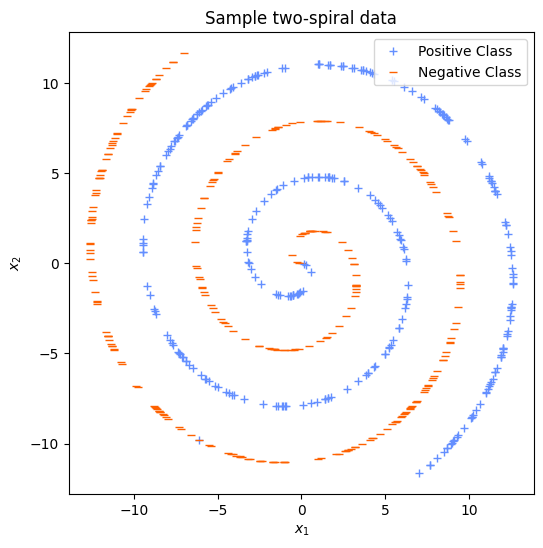

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Produces two spirals
def twoSpirals(N):
  np.random.seed(1)
  n = np.sqrt(np.random.rand(N,1)) * 780 * (2*np.pi)/360
  x = -np.cos(n)*n
  y = np.sin(n)*n
  return (np.vstack((np.hstack((x,y)),np.hstack((-x,-y)))),
          np.hstack((np.ones(N)*-1,np.ones(N))))

X, y = twoSpirals(300)
fig = plt.figure(figsize=(6,6))

plt.plot(X[1,0],X[1,1],'+', color='#648fff', label='Positive Class')
plt.plot(X[2,1],X[2,1],'_', color='#fe6100', label='Negative Class')

for i in range(len(y)):
  x1 = X[i,0]
  x2 = X[i,1]
  if (y[i] == 1):
    plt.plot(x1,x2,'+', color='#648fff')
  else:
    plt.plot(x1,x2,'k_', color='#fe6100')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.title('Sample two-spiral data')
plt.axis('tight')
plt.savefig('ch.6.two-spiral.data.png', dpi=350, bbox_inches='tight')
# plt.savefig('ch.6.two-spiral.data.eps', dpi=350, bbox_inches='tight')
plt.show()

Tensorflow and Keras

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0


##Minimizing The Error on the MLP

## Hyper-parameter optimization experiments
Epoch and batch sized

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

y = (y == 1).astype(int)
# Convert to one-hot encoding → shape (N,2)
y = to_categorical(y, num_classes=2)

mlp = Sequential()
mlp.add(Dense(3, input_dim=2, activation='sigmoid'))
mlp.add(Dense(2, activation='sigmoid'))

mlp.compile(loss='mean_squared_error',
            optimizer='sgd',
            metrics=['accuracy'])

# trains the model
mlp.fit(X, y, epochs=100, batch_size=60,
        verbose=1)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4216 - loss: 0.2698  
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4216 - loss: 0.2694 
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4227 - loss: 0.2688 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4366 - loss: 0.2671 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4226 - loss: 0.2692 
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4246 - loss: 0.2681 
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4285 - loss: 0.2674 
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3924 - loss: 0.2694 
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3911 - loss: 0.2691 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4032 - loss: 0.2680 
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4153 - loss: 0.2670 
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

epochs=1000, batch_size=60

with 600 samples:

600/60=10 batches per epoch
600/60=10 batches per epoch

So in one epoch:

Batch 1 → 60 samples → update weights

Batch 2 → 60 samples → update weights

...

Batch 10 → 60 samples → update weights

So per epoch you get:

10 weight updates



We use 16, 32, 64, 128 because computers and GPUs are optimized for powers of two. It’s a hardware efficiency convention, not a mathematical rule



In [ ]:
predictions = mlp.predict(X)
print(predictions[:5])

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
[[0.42362958 0.468102  ]
 [0.51822644 0.52173537]
 [0.47379214 0.49509558]
 [0.4555923  0.52534366]
 [0.5118676  0.50961906]]


In [ ]:
import numpy as np

predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y, axis=1)

print(predicted_classes[:5])
print(true_classes[:5])

[1 1 1 1 0]
[0 0 0 0 0]


Loss and acc plots

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import numpy as np

# Produces two spirals
def twoSpirals(N):
  np.random.seed(1)
  n = np.sqrt(np.random.rand(N,1)) * 780 * (2*np.pi)/360
  x = -np.cos(n)*n
  y = np.sin(n)*n
  return (np.vstack((np.hstack((x,y)),np.hstack((-x,-y)))),
          np.hstack((np.ones(N)*-1,np.ones(N))))

X, y = twoSpirals(300)


y = (y == 1).astype(int)
# Convert to one-hot encoding → shape (N,2)
y = to_categorical(y, num_classes=2)

mlp = Sequential()
mlp.add(Dense(3, input_dim=2, activation='sigmoid'))
mlp.add(Dense(2, activation='sigmoid'))

mlp.compile(loss='mean_squared_error',
            optimizer='sgd',
            metrics=['accuracy'])

# trains the model
history = mlp.fit(X, y, epochs=100, batch_size=60
        ,verbose=1) #Shows a progress bar per epoch

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4259 - loss: 0.2744  
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3907 - loss: 0.2741 
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3891 - loss: 0.2737 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3766 - loss: 0.2758 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3739 - loss: 0.2747 
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3716 - loss: 0.2736 
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3645 - loss: 0.2755 
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3824 - loss: 0.2693 
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3641 - loss: 0.2723 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3716 - loss: 0.2727 
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3701 - loss: 0.2721 
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

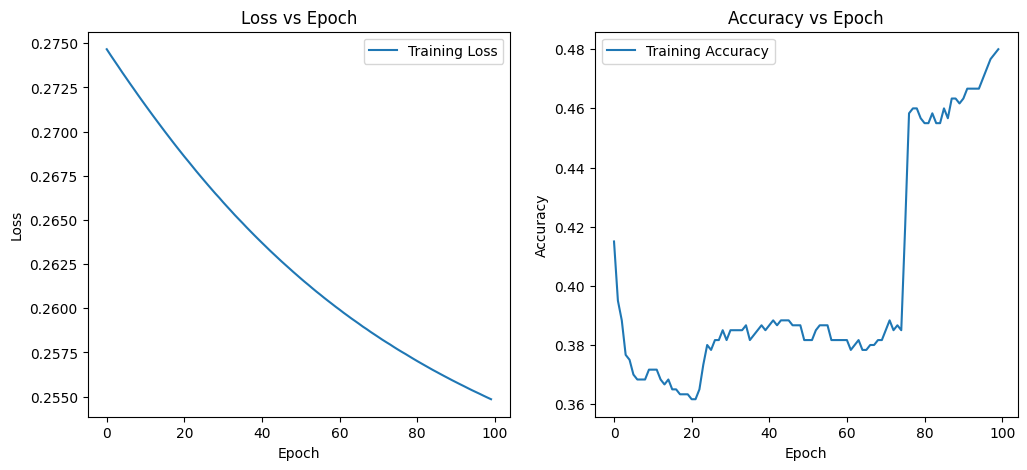

In [ ]:
plt.figure(figsize=(12,5))

# ----- Loss Plot -----
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()

# ----- Accuracy Plot -----
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()

plt.show()


verbose  shows a progress bar per epoch if 1



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import numpy as np

# Produces two spirals
def twoSpirals(N):
  np.random.seed(1)
  n = np.sqrt(np.random.rand(N,1)) * 780 * (2*np.pi)/360
  x = -np.cos(n)*n
  y = np.sin(n)*n
  return (np.vstack((np.hstack((x,y)),np.hstack((-x,-y)))),
          np.hstack((np.ones(N)*-1,np.ones(N))))

X, y = twoSpirals(300)


y = (y == 1).astype(int)
# Convert to one-hot encoding → shape (N,2)
y = to_categorical(y, num_classes=2)

mlp = Sequential()
mlp.add(Dense(3, input_dim=2, activation='sigmoid'))
mlp.add(Dense(2, activation='sigmoid'))

mlp.compile(loss='mean_squared_error',
            optimizer='sgd',
            metrics=['accuracy'])

# trains the model
history = mlp.fit(X, y, epochs=100, batch_size=60
         ,verbose=0)  #Shows a progress bar per epoch if 1


Activation function

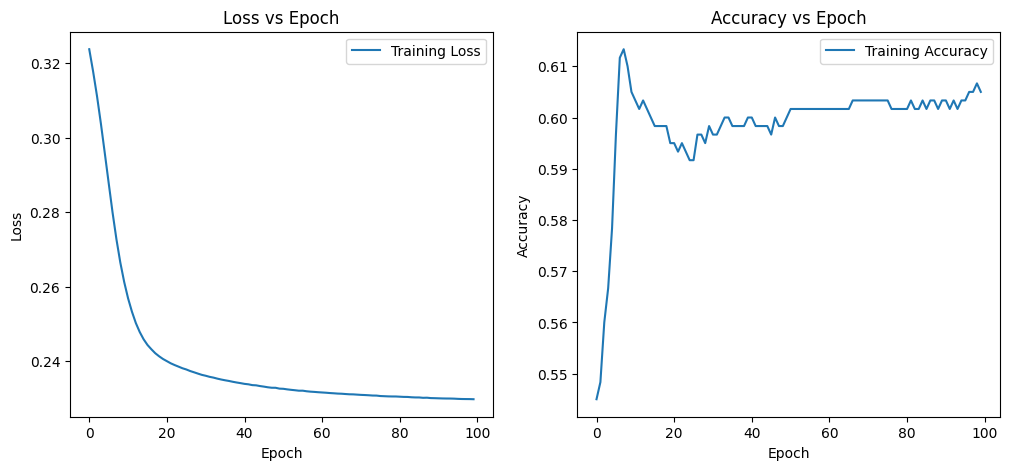

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import numpy as np

# Produces two spirals
def twoSpirals(N):
  np.random.seed(1)
  n = np.sqrt(np.random.rand(N,1)) * 780 * (2*np.pi)/360
  x = -np.cos(n)*n
  y = np.sin(n)*n
  return (np.vstack((np.hstack((x,y)),np.hstack((-x,-y)))),
          np.hstack((np.ones(N)*-1,np.ones(N))))

X, y = twoSpirals(300)


y = (y == 1).astype(int)
# Convert to one-hot encoding → shape (N,2)
y = to_categorical(y, num_classes=2)

mlp = Sequential()
mlp.add(Dense(3, input_dim=2, activation='relu'))
mlp.add(Dense(2, activation='sigmoid'))

mlp.compile(loss='mean_squared_error',
            optimizer='sgd',
            metrics=['accuracy'])

# trains the model
history = mlp.fit(X, y, epochs=100, batch_size=60
         ,verbose=0)  #Shows a progress bar per epoch if 1
plt.figure(figsize=(12,5))

# ----- Loss Plot -----
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()

# ----- Accuracy Plot -----
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()

plt.show()

Number of neurons and layers

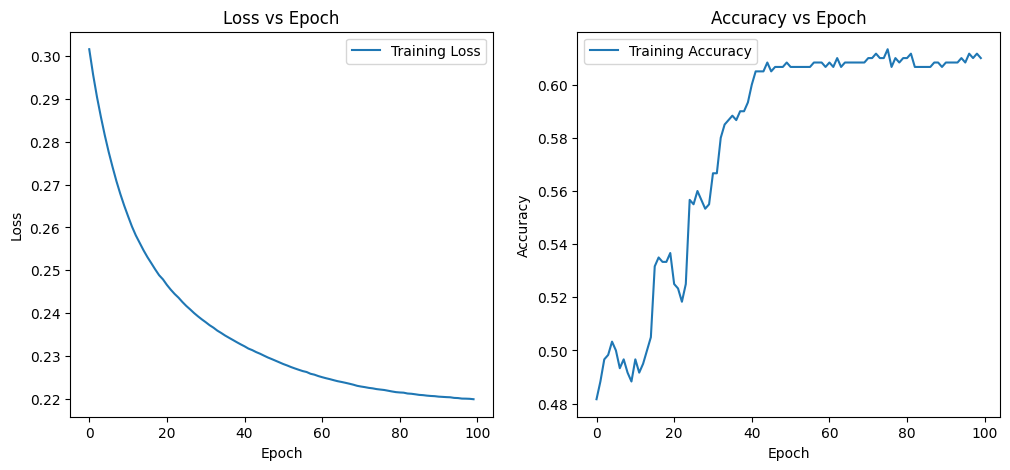

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import numpy as np

# Produces two spirals
def twoSpirals(N):
  np.random.seed(1)
  n = np.sqrt(np.random.rand(N,1)) * 780 * (2*np.pi)/360
  x = -np.cos(n)*n
  y = np.sin(n)*n
  return (np.vstack((np.hstack((x,y)),np.hstack((-x,-y)))),
          np.hstack((np.ones(N)*-1,np.ones(N))))

X, y = twoSpirals(300)


y = (y == 1).astype(int)
# Convert to one-hot encoding → shape (N,2)
y = to_categorical(y, num_classes=2)

mlp = Sequential()
mlp.add(Dense(16, input_dim=2, activation='relu'))
mlp.add(Dense(16, activation='relu'))
mlp.add(Dense(16, activation='relu'))
mlp.add(Dense(2, activation='sigmoid'))

mlp.compile(loss='mean_squared_error',
            optimizer='sgd',
            metrics=['accuracy'])

# trains the model
history = mlp.fit(X, y, epochs=100, batch_size=60
         ,verbose=0)  #Shows a progress bar per epoch if 1
plt.figure(figsize=(12,5))

# ----- Loss Plot -----
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()

# ----- Accuracy Plot -----
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()

plt.show()

reduce_lr
factor=0.5, new LR=old LR×0.5  =>  0.01 → 0.005 → 0.0025 → ...


If performance stops improving,

Big steps cause oscillation

So we reduce LR to fine-tune


 patience=100 means
Wait 100 epochs without improvement before reducing the learning rate.

Final learning rate: 0.009999999776482582


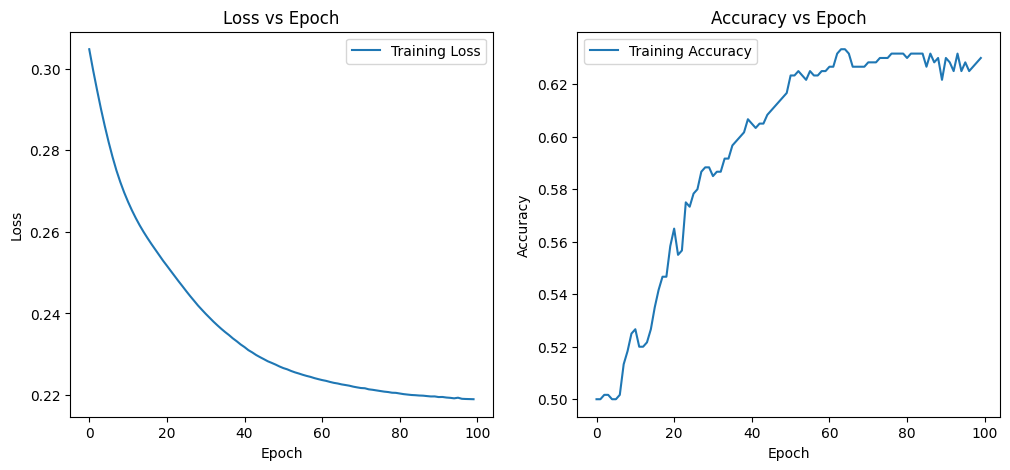

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ReduceLROnPlateau
import numpy as np

# Produces two spirals
def twoSpirals(N):
  np.random.seed(1)
  n = np.sqrt(np.random.rand(N,1)) * 780 * (2*np.pi)/360
  x = -np.cos(n)*n
  y = np.sin(n)*n
  return (np.vstack((np.hstack((x,y)),np.hstack((-x,-y)))),
          np.hstack((np.ones(N)*-1,np.ones(N))))

X, y = twoSpirals(300)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

y = (y == 1).astype(int)
# Convert to one-hot encoding → shape (N,2)
y = to_categorical(y, num_classes=2)

mlp = Sequential()
mlp.add(Dense(16, input_dim=2, activation='relu'))
mlp.add(Dense(16, activation='relu'))
mlp.add(Dense(16, activation='relu'))
mlp.add(Dense(2, activation='sigmoid'))

reduce_lr = ReduceLROnPlateau(monitor='accuracy', factor=0.5,
                              patience=100, min_lr=0.00000001,
                              verbose = 1)

mlp.compile(loss='mean_squared_error',
            optimizer='sgd',     # default learning rate in 0.01
            metrics=['accuracy'])

# trains the model
history = mlp.fit(X, y, epochs=100, batch_size=60,
        verbose=0, callbacks=[reduce_lr]
       )
import tensorflow as tf

lr = mlp.optimizer.learning_rate
# lr can be a float, tf.Variable, or schedule
print("Final learning rate:", float(tf.keras.backend.get_value(lr)))
plt.figure(figsize=(12,5))

# ----- Loss Plot -----
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()

# ----- Accuracy Plot -----
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()

plt.show()


Epoch 229: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.

Epoch 329: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.

Epoch 429: ReduceLROnPlateau reducing learning rate to 0.0012499999720603228.

Epoch 529: ReduceLROnPlateau reducing learning rate to 0.0006249999860301614.

Epoch 629: ReduceLROnPlateau reducing learning rate to 0.0003124999930150807.

Epoch 729: ReduceLROnPlateau reducing learning rate to 0.00015624999650754035.

Epoch 829: ReduceLROnPlateau reducing learning rate to 7.812499825377017e-05.

Epoch 929: ReduceLROnPlateau reducing learning rate to 3.9062499126885086e-05.
Final learning rate: 3.9062499126885086e-05


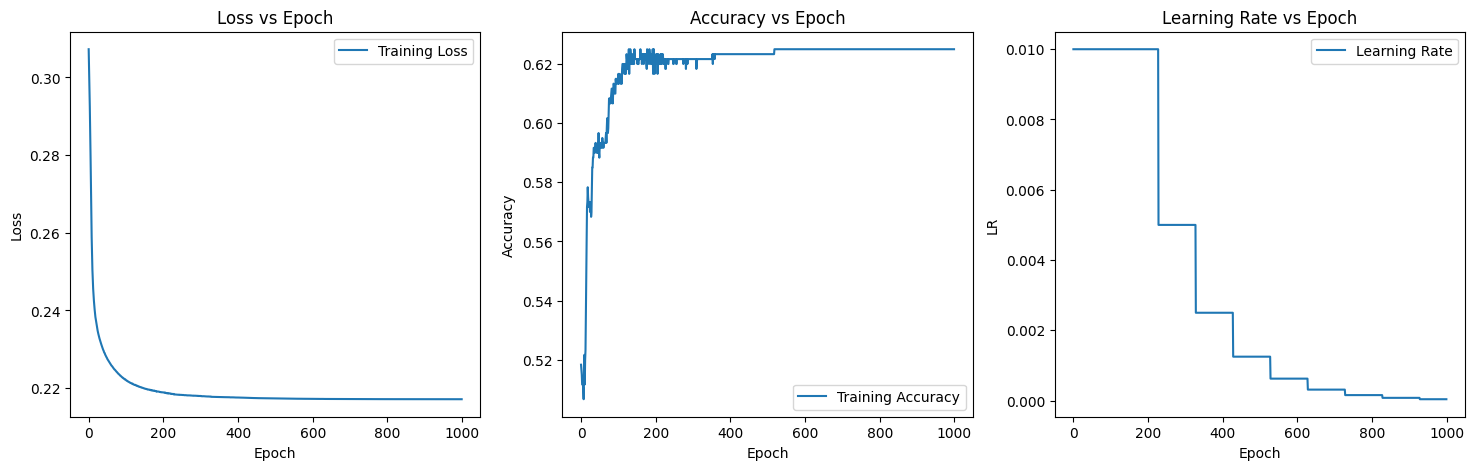

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Produces two spirals
def twoSpirals(N):
  np.random.seed(1)
  n = np.sqrt(np.random.rand(N,1)) * 780 * (2*np.pi)/360
  x = -np.cos(n)*n
  y = np.sin(n)*n
  return (np.vstack((np.hstack((x,y)),np.hstack((-x,-y)))),
          np.hstack((np.ones(N)*-1,np.ones(N))))

X, y = twoSpirals(300)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

y = (y == 1).astype(int)
y = to_categorical(y, num_classes=2)

mlp = Sequential()
mlp.add(Dense(16, input_dim=2, activation='relu'))
mlp.add(Dense(16, activation='relu'))
mlp.add(Dense(16, activation='relu'))
mlp.add(Dense(2, activation='sigmoid'))

reduce_lr = ReduceLROnPlateau(
    monitor='accuracy', factor=0.5,
    patience=100, min_lr=1e-8,
    verbose=1
)

mlp.compile(loss='mean_squared_error',
            optimizer='sgd',     # default learning rate is 0.01
            metrics=['accuracy'])

# ---- NEW: callback to log LR each epoch ----
class LrLogger(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.lrs = []
    def on_epoch_end(self, epoch, logs=None):
        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        self.lrs.append(lr)

lr_logger = LrLogger()

# trains the model
history = mlp.fit(
    X, y, epochs=1000, batch_size=60,
    verbose=0, callbacks=[reduce_lr, lr_logger]
)

# Print final LR
print("Final learning rate:", lr_logger.lrs[-1])

# ---- Plots ----
plt.figure(figsize=(18,5))

# Loss
plt.subplot(1,3,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()

# Accuracy
plt.subplot(1,3,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()

# Learning rate
plt.subplot(1,3,3)
plt.plot(lr_logger.lrs, label='Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.title('Learning Rate vs Epoch')
plt.legend()

plt.show()